1. Euclidean Distance
- Là khoảng cách đường thẳng giữa hai điểm trong không gian.
- Thường dùng trong KNN và K-Means khi dữ liệu là số và có cùng thang đo.
2. Cosine Distance
- Đo sự khác biệt về hướng giữa hai vector, không quá quan tâm đến độ lớn của chúng.
- Rất phổ biến trong text similarity, embeddings và recommendation systems.
3. Hamming Distance
- Đo số vị trí khác nhau giữa hai chuỗi hoặc hai vector.
- Phù hợp với binary features, hashing và error detection.
4. Manhattan Distance
- Đo khoảng cách theo kiểu đi ngang và dọc, giống như di chuyển theo các ô phố.
- Hay dùng trong các bài toán grid-based hoặc di chuyển theo từng bước.
5. Minkowski Distance
- Là dạng tổng quát của nhiều loại khoảng cách khác, giúp linh hoạt hơn trong cách đo.
- Dùng khi muốn điều chỉnh cách tính khoảng cách cho phù hợp với bài toán.
6. Jaccard Distance
- Đo mức độ khác nhau giữa hai tập hợp dựa trên phần giao và phần hợp.
- Thường dùng trong recommendation systems, so sánh tags hoặc hành vi người dùng.
7. Chebyshev Distance
- Chỉ quan tâm đến độ chênh lệch lớn nhất trên một chiều bất kỳ.
- Hữu ích khi khác biệt lớn nhất là yếu tố quan trọng nhất.
8. Haversine Distance
- Dùng để tính khoảng cách giữa hai điểm trên bề mặt Trái Đất.
- Rất quan trọng trong bản đồ, điều hướng và dịch vụ theo vị trí.
9. Sorensen-Dice Distance
- Là một dạng distance dựa trên độ tương đồng, ưu tiên mạnh hơn cho các phần tử chung.
- Thường dùng trong NLP, document similarity và dữ liệu sinh học.

In [3]:
"""
    - đọc ảnh → grayscale
    - chuẩn hóa (resize 100x100 + hist equalization)
    - trích vector (Eigenface / LBP / HOG)
    - vectors.append(vector)
"""
import cv2 as cv
import numpy as np
from pathlib import Path

def preprocess(img_path):

    data = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv.imdecode(data, cv.IMREAD_GRAYSCALE)

    if img is None:
        print("Cannot read:", img_path)
        return None

    img = cv.resize(img, (100, 100))
    img = cv.equalizeHist(img)

    return img.flatten()


In [4]:
# Update [Image => Augment => HoG/LBP/Eigenface]
def augment(img_path):
    data = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv.imdecode(data, cv.IMREAD_GRAYSCALE)
    if img is None:
        return []

    results = []

    candidates = [img]
    h,w = img.shape
    center = (w//2, h//2)
    for angle in [-20, -15, -5, 5, 10, 15, 20]:
        M = cv.getRotationMatrix2D(center, angle, 1.0)
        rotated = cv.warpAffine(img, M, (w,h))
        candidates.append(rotated)

    for beta in [-30, 30]:
        bright = cv.convertScaleAbs(img, alpha=1.0, beta=beta)
        candidates.append(bright)

    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    noisy = np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)
    candidates.append(noisy)

    for candidate in candidates:
        resized = cv.resize(candidate, (100, 100))
        equalized = cv.equalizeHist(resized)
        results.append(equalized.flatten())
    
    return results
def generating(img_path, init_vec):
    results = augment(img_path)
    return [init_vec] + results

In [5]:
# Update [Image => Face Alignment => Augment => LBP/Eigenface/HoG]
eye_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_eye.xml"
)
face_cascade = cv.CascadeClassifier(
    cv.data.haarcascades + "haarcascade_frontalface_default.xml"
)
def read_img(img_path):
    data = np.fromfile(str(img_path), dtype=np.uint8)
    img = cv.imdecode(data, cv.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return img
def align_face(img_path):
    img = read_img(img_path)

    # 1. detect face trước
    faces = face_cascade.detectMultiScale(img, 1.1, 5)
    if len(faces) == 0:
        return None

    # lấy face lớn nhất
    x, y, w, h = max(faces, key=lambda f: f[2]*f[3])
    face = img[y:y+h, x:x+w]

    # 2. detect eyes trong face
    eyes = eye_cascade.detectMultiScale(face, 1.1, 5)
    if len(eyes) < 2:
        return None

    # 3. lấy 2 mắt
    eyes = sorted(eyes, key=lambda e: e[0])[:2]

    (x1, y1, w1, h1), (x2, y2, w2, h2) = eyes

    left_eye = (x1 + w1//2, y1 + h1//2)
    right_eye = (x2 + w2//2, y2 + h2//2)

    # 4. tính góc
    dx = right_eye[0] - left_eye[0]
    dy = right_eye[1] - left_eye[1]
    angle = np.degrees(np.arctan2(dy, dx))

    # 5. rotate
    center = (face.shape[1]//2, face.shape[0]//2)
    M = cv.getRotationMatrix2D(center, angle, 1.0)
    aligned = cv.warpAffine(face, M, (face.shape[1], face.shape[0]))

    return aligned
def augment_from_img(img):
    candidates = [img]
    h, w = img.shape
    center = (w // 2, h // 2)

    for angle in [-20, -15, -5, 5, 10, 15, 20]:
        M = cv.getRotationMatrix2D(center, angle, 1.0)
        candidates.append(cv.warpAffine(img, M, (w, h)))

    for beta in [-30, 30]:
        candidates.append(cv.convertScaleAbs(img, alpha=1.0, beta=beta))

    noise = np.random.normal(0, 10, img.shape).astype(np.float32)
    candidates.append(np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8))

    return [c.flatten() for c in candidates]

In [6]:
image_paths = r"./datasource"
dataset_path = Path(image_paths)

# Collecting without augment
def collecting_v1(dataset_path):
    all_vectors = []
    labels = []
    for folder in dataset_path.iterdir():
        if folder.is_dir():
            for image_dir in folder.iterdir():
                if image_dir.is_dir():
                    for image_file in image_dir.iterdir():
                        if image_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                            vec = preprocess(image_file)
                            all_vectors.append(vec)
                            labels.append(image_dir.name)
    return all_vectors, labels

# Collecting with augment
def collecting_v2(dataset_path):
    all_vectors = []
    labels = []
    for folder in dataset_path.iterdir():
        if folder.is_dir():
            for image_dir in folder.iterdir():
                if image_dir.is_dir():
                    for image_file in image_dir.iterdir():
                        if image_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                            vec = preprocess(image_file)
                            augmented_vecs = generating(image_file, vec)
                            for vec in augmented_vecs:
                                all_vectors.append(vec)
                                labels.append(image_dir.name)
    return all_vectors, labels

# Collecting with face_alignment
def collecting_v3(dataset_path):
    all_vectors = []
    labels = []
    skipped = 0

    for folder in dataset_path.iterdir():
        if not folder.is_dir():
            continue
        for image_dir in folder.iterdir():
            if not image_dir.is_dir():
                continue
            for image_file in image_dir.iterdir():
                if image_file.suffix.lower() not in [".jpg", ".jpeg", ".png"]:
                    continue
                
                img = read_img(image_file)
                if img is None:
                    continue

                # 1. Alignment trước
                aligned = align_face(image_file)
                if aligned is None:
                    skipped += 1
                    continue

                # 2. Preprocess
                resized   = cv.resize(aligned, (100, 100))
                equalized = cv.equalizeHist(resized)

                # 3. Augment
                augmented = augment_from_img(equalized)  # augment từ img trực tiếp
                for vec in augmented:
                    all_vectors.append(vec)
                    labels.append(image_dir.name)

    print(f"Bỏ qua {skipped} ảnh không detect được mắt")
    return all_vectors, labels

In [7]:
# # Test với Akira Phan
# vectors, labels = collecting_v3(dataset_path)
# print(f"Vectors: {len(vectors)}, Labels: {len(labels)}")

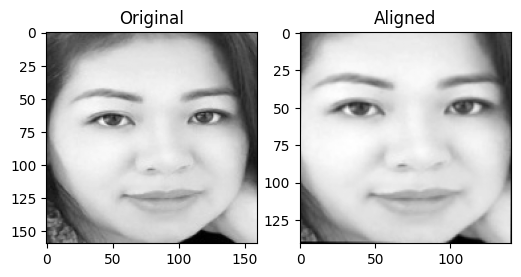

In [20]:
import matplotlib.pyplot as plt
def debug_alignment(image_path):
    img = read_img(image_path)
    aligned = align_face(image_path) 

    if aligned is None:
        print("Alignment failed")
        return

    plt.figure(figsize=(6,3))
    plt.subplot(1,2,1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")

    plt.subplot(1,2,2)
    plt.imshow(aligned, cmap='gray')
    plt.title("Aligned")

    plt.show()

debug_alignment("./datasource/Ca sĩ/ca sĩ Anh Thơ/1671998326058472000.jpg")
img = read_img("./datasource/Ca sĩ/ca sĩ Anh Thơ/1671998326058472000.jpg")

cv.imshow("Original Image", img)
cv.waitKey(0)
cv.destroyAllWindows()

In [8]:
# vectors, labels = collecting_v2(dataset_path)
# print(f"Số vectors: {len(vectors)}")
# print(f"Số labels:  {len(labels)}")
# print(f"Bằng nhau:  {len(vectors) == len(labels)}")

# # Kiểm tra số ảnh gốc vs sau augment
# vectors_v1, _ = collecting_v1(dataset_path)
# akira_count = sum(1 for l in _ if l == "ca sĩ Akira Phan")
# print(f"Ảnh gốc Akira Phan: {akira_count}")
# print(f"Sau augment:        {len(vectors)}")
# print(f"Tỉ lệ tăng:         {len(vectors)/akira_count:.1f}x")

In [7]:
import numpy as np
# Feature Extractors => vector
def eigenface(vectors, n_components = 50):
    X = np.array(vectors, dtype=np.float32)
    meanface = np.mean(X, axis=0)
    X_centered = X - meanface
    # SVD để tìm ra các hướng biến thiên chính
    _, _, Vt = np.linalg.svd(X_centered, full_matrices=False)
    eigenfaces = Vt[: n_components] # Giữ hướng quan trọng nhất
    return meanface, eigenfaces
def hog():
    pass
def lbp():
    pass

In [8]:
import re
import unicodedata
from pathlib import Path

def normalize_label(label):
    ascii_label = unicodedata.normalize("NFD", label)
    ascii_label = "".join(ch for ch in ascii_label if unicodedata.category(ch) != "Mn")
    ascii_label = ascii_label.encode("ascii", "ignore").decode("ascii")
    ascii_label = ascii_label.lower().strip()
    ascii_label = re.sub(r"[^a-z0-9]+", "_", ascii_label)
    ascii_label = re.sub(r"_+", "_", ascii_label).strip("_")
    return ascii_label or "unknown"

def store_db_npz(db_file, file_path):
    payload = {}
    label_keys = []
    label_values = []

    for key, value in db_file.items():
        if key == "label_map":
            label_keys = np.array(list(value.keys()), dtype="U")
            label_values = np.array(list(value.values()), dtype="U")
            continue
        payload[key] = np.asarray(value, dtype=np.float32)

    payload["label_keys"] = label_keys
    payload["label_values"] = label_values
    np.savez(file_path, **payload)

In [9]:
# Eigenface implement
def standardize(vector, meanface):
    return np.array(vector, dtype=np.float32) - meanface

def project_to_eigenface_space(vector, meanface, eigenfaces):
    centered_vector = standardize(vector, meanface)
    return centered_vector @ eigenfaces.T
def get_most(vectors):
    if len(vectors) == 0:
        raise ValueError("Empty vector list")
    return np.mean(np.stack(vectors), axis=0)

def cosine_similarity(a, b):
    return np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
def identify_face_cosine(vector, db):
    best_label = None
    best_score = -1
    meanface = db["meanface"]
    eigenfaces = db["eigenfaces"]
    feature = project_to_eigenface_space(vector, meanface, eigenfaces)

    for label, stored_vector in db.items():
        if label in ["meanface", "eigenfaces", "label_map"]:
            continue
        similarity = cosine_similarity(feature, stored_vector)
        if similarity > best_score:
            best_score = similarity
            best_label = label
    display_label = db["label_map"].get(best_label, best_label)
    return display_label, best_score

def identify_face_euclidean(vector, db):
    best_label = None
    best_distance = float("inf")
    meanface = db["meanface"]
    eigenfaces = db["eigenfaces"]
    feature = project_to_eigenface_space(vector, meanface, eigenfaces)

    for label, stored_vector in db.items():
        if label in ["meanface", "eigenfaces", "label_map"]:
            continue
        distance = np.linalg.norm(feature - stored_vector)
        if distance < best_distance:
            best_distance = distance
            best_label = label

    display_label = db["label_map"].get(best_label, best_label)
    return display_label, best_distance

In [ ]:
# # Setup Eigenface -- done
db = {}
vectors, labels = collecting_v3(dataset_path)
meanface, eigenfaces = eigenface(vectors)
db["meanface"] = meanface.astype(np.float32)
db["eigenfaces"] = eigenfaces.astype(np.float32)
db["label_map"] = {}
print("eigenfaces shape:", eigenfaces.shape)
print("meanface shape:", meanface.shape)

# Store feature PCA in file npz
feature_groups = {}
for vector, label in zip(vectors, labels):
    normalized_label = normalize_label(label)
    db["label_map"][normalized_label] = label
    feature_vector = project_to_eigenface_space(vector, meanface, eigenfaces)
    feature_groups.setdefault(normalized_label, []).append(feature_vector)

for normalized_label, feature_vectors in feature_groups.items():
    db[normalized_label] = get_most(feature_vectors).astype(np.float32)

output_path = Path("outputs") / "eigenface_vector_augmented_face_alignment.npz"
output_path.parent.mkdir(parents=True, exist_ok=True)
store_db_npz(db, output_path)
print("saved npz:", output_path)
print("normalized labels:", list(db["label_map"].keys()))


In [11]:
import cv2 as cv
import matplotlib.pyplot as plt

def load_db_npz(file_path):
    data = np.load(file_path, allow_pickle=False)
    loaded_db = {}

    for key in data.files:
        if key in ["label_keys", "label_values"]:
            continue
        loaded_db[key] = data[key]

    label_keys = data.get("label_keys", np.array([], dtype="U")).tolist()
    label_values = data.get("label_values", np.array([], dtype="U")).tolist()
    loaded_db["label_map"] = dict(zip(label_keys, label_values))
    return loaded_db

def capture_face_vector(camera_index=0):
    face_model = cv.data.haarcascades + "haarcascade_frontalface_default.xml"
    detector = cv.CascadeClassifier(face_model)
    cap = cv.VideoCapture(camera_index)

    if not cap.isOpened():
        print("Cannot open camera")
        return None, None

    captured_vector = None
    captured_face = None

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        gray = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        faces = detector.detectMultiScale(gray, scaleFactor=1.1, minNeighbors=5)

        for (x, y, w, h) in faces:
            cv.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

        cv.imshow("Press SPACE to capture face / ESC to cancel", frame)
        key = cv.waitKey(1) & 0xFF

        if key == 27:
            break

        if key == 32 and len(faces) > 0:
            x, y, w, h = max(faces, key=lambda item: item[2] * item[3])
            padding = 0.2  # bạn có thể tune: 0.2 → 0.5
            x_pad = int(w * padding)
            y_pad = int(h * padding)

            x1 = max(0, x - x_pad)
            y1 = max(0, y - y_pad)
            x2 = min(gray.shape[1], x + w + x_pad)
            y2 = min(gray.shape[0], y + h + y_pad)

            face_roi = gray[y1:y2, x1:x2]
            face_roi = cv.resize(face_roi, (100, 100))
            face_roi = cv.equalizeHist(face_roi)
            captured_face = face_roi.copy()
            captured_vector = face_roi.flatten().astype(np.float32)
            break

    cap.release()
    cv.destroyAllWindows()
    return captured_vector, captured_face

def find_reference_image(label, dataset_root):
    for folder in Path(dataset_root).iterdir():
        if not folder.is_dir():
            continue
        for image_dir in folder.iterdir():
            if not image_dir.is_dir() or image_dir.name != label:
                continue
            for image_file in image_dir.iterdir():
                if image_file.suffix.lower() in [".jpg", ".jpeg", ".png"]:
                    return image_file
    return None

def read_image_for_plot(image_path):
    raw = np.fromfile(str(image_path), dtype=np.uint8)
    image = cv.imdecode(raw, cv.IMREAD_COLOR)
    if image is None:
        return None
    return cv.cvtColor(image, cv.COLOR_BGR2RGB)

# loaded_db = load_db_npz(Path("outputs") / "eigenface_vector_augmented.npz")
# test_vector, captured_face = capture_face_vector()

# if test_vector is not None:
#     predicted_label, distance = identify_face_cosine(test_vector, loaded_db)
#     print("predicted label:", predicted_label)
#     print("distance:", distance)

#     reference_image_path = find_reference_image(predicted_label, dataset_path)
#     if reference_image_path is None:
#         print("Cannot find reference image for:", predicted_label)
#     else:
#         reference_image = read_image_for_plot(reference_image_path)

#         plt.figure(figsize=(8, 4))
#         plt.subplot(1, 2, 1)
#         plt.imshow(captured_face, cmap="gray")
#         plt.title("Captured face")
#         plt.axis("off")

#         plt.subplot(1, 2, 2)
#         plt.imshow(reference_image)
#         plt.title(predicted_label) 
#         plt.axis("off")

#         plt.tight_layout() 
#         plt.show()
# else:
#     print("No face captured.")


In [12]:
# ─── HOG Feature Extraction ──────────────────────────────────
def extract_hog(img_or_vec):
    arr = np.asarray(img_or_vec, dtype=np.float32)

    # collecting_v1() currently returns flattened 100x100 vectors
    if arr.ndim == 1:
        if arr.size != 100 * 100:
            raise ValueError(f"Expected flattened 100x100 vector, got size={arr.size}")
        arr = arr.reshape(100, 100)
    elif arr.ndim != 2:
        raise ValueError(f"Expected 2D image or 1D flattened vector, got shape={arr.shape}")
    features = hog(
        arr,
        orientations=9,
        pixels_per_cell=(8, 8),
        cells_per_block=(2, 2),
        visualize=False,
        feature_vector=True
    )
    return features.astype(np.float32)

In [14]:
%pip install scikit-image

   ---------------------------------------- 0.0/11.9 MB ? eta -:--:--
    --------------------------------------- 0.3/11.9 MB ? eta -:--:--
   ---- ----------------------------------- 1.3/11.9 MB 4.2 MB/s eta 0:00:03
   ------- -------------------------------- 2.1/11.9 MB 3.9 MB/s eta 0:00:03
   ---------- ----------------------------- 3.1/11.9 MB 4.1 MB/s eta 0:00:03
   ------------- -------------------------- 3.9/11.9 MB 4.1 MB/s eta 0:00:02
   -------------- ------------------------- 4.2/11.9 MB 4.0 MB/s eta 0:00:02
   --------------- ------------------------ 4.7/11.9 MB 3.6 MB/s eta 0:00:02
   ---------------- ----------------------- 5.0/11.9 MB 3.4 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/11.9 MB 3.0 MB/s eta 0:00:03
   ------------------ --------------------- 5.5/11.9 MB 3.0 MB/s eta 0:00:03
   -------------------- ------------------- 6.0/11.9 MB 2.7 MB/s eta 0:00:03
   -------------------- ------------------- 6.0/11.9 MB 2.7 MB/s eta 0:00:03
   ----------

In [15]:
from skimage.feature import hog
import numpy as np
from pathlib import Path
# Build db HOG
vectors, labels = collecting_v2(dataset_path)  # vectors are flattened 100x100 from preprocess()
db_hog = {"label_map": {}}
feature_groups = {}

for vector, label in zip(vectors, labels):
    if vector is None:
        continue
    normalized_label = normalize_label(label)
    db_hog["label_map"][normalized_label] = label

    hog_vec = extract_hog(vector)
    feature_groups.setdefault(normalized_label, []).append(hog_vec)

# Store class centroid (mean HOG vector)
for normalized_label, group in feature_groups.items():
    db_hog[normalized_label] = np.mean(np.stack(group), axis=0).astype(np.float32)

output_path = Path("outputs") / "hog_vector_augmented_face_aligned.npz"
output_path.parent.mkdir(parents=True, exist_ok=True)
store_db_npz(db_hog, output_path)

print("saved npz:", output_path)
print("num labels:", len(db_hog["label_map"]))
print("normalized labels:", list(db_hog["label_map"].keys()))

saved npz: outputs\hog_vector_augmented_face_aligned.npz
num labels: 224
normalized labels: ['ca_si_akira_phan', 'ca_si_anh_tho', 'ca_si_bigdaddy', 'ca_si_bich_phuong', 'ca_si_bui_anh_tuan', 'ca_si_bao_anh', 'ca_si_bao_thy', 'ca_si_bang_kieu', 'ca_si_cao_thai_son', 'ca_si_chi_dan', 'ca_si_cat_tuong', 'ca_si_cam_ly', 'ca_si_don_nguyen', 'ca_si_doan_hieu', 'ca_si_duong_trieu_vu', 'ca_si_dich_duong_thien_ti', 'ca_si_emily', 'ca_si_enrique_iglesias', 'ca_si_erik', 'ca_si_fanny_tran', 'ca_si_gin_tuan_kiet', 'ca_si_hari_won', 'ca_si_hien_thuc', 'ca_si_hoai_lam', 'ca_si_hoang_thuy_linh', 'ca_si_hoang_yen_chibi', 'ca_si_ha_anh_tuan', 'ca_si_ha_thanh_xuan', 'ca_si_hoa_minzy', 'ca_si_hai_bang', 'ca_si_ho_ngoc_ha', 'ca_si_ho_quang_hieu', 'ca_si_ho_quynh_huong', 'ca_si_ho_van_cuong', 'ca_si_jang_mi', 'ca_si_justatee', 'ca_si_k_icm', 'ca_si_karik', 'ca_si_kelvin_khanh', 'ca_si_khanh_phuong', 'ca_si_khong_tu_quynh', 'ca_si_khoi_my', 'ca_si_kyo_york', 'ca_si_lam_truong', 'ca_si_leg', 'ca_si_luna_ao',

predicted label: ca sĩ Karik
cosine score: 0.726498007774353


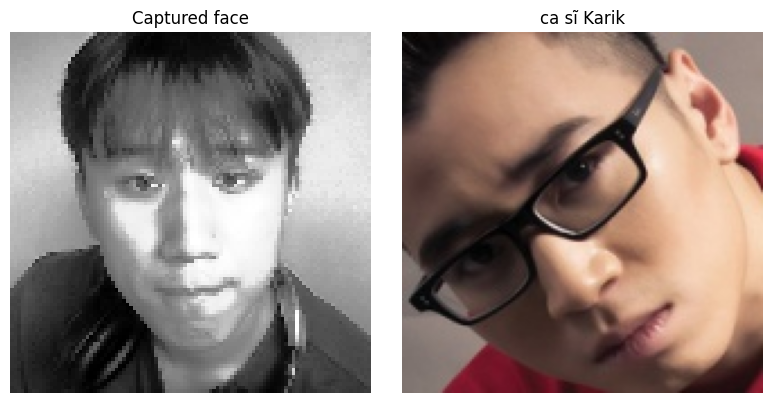

In [15]:
# HOG inference (cosine similarity)
def cosine_similarity(a, b):
    denom = np.linalg.norm(a) * np.linalg.norm(b)
    if denom == 0:
        return -1.0
    return float(np.dot(a, b) / denom)

def identify_face_hog_cosine(vector, db_hog):
    query_feature = extract_hog(vector)
    best_label = None
    best_score = -1.0

    for label, stored_feature in db_hog.items():
        if label == "label_map":
            continue
        score = cosine_similarity(query_feature, stored_feature)
        if score > best_score:
            best_score = score
            best_label = label

    display_label = db_hog["label_map"].get(best_label, best_label)
    return display_label, best_score

hog_db_path = Path("outputs") / "hog_vector.npz"
loaded_hog_db = load_db_npz(hog_db_path)

test_vector, captured_face = capture_face_vector()

if test_vector is not None:
    predicted_label, score = identify_face_hog_cosine(test_vector, loaded_hog_db)
    print("predicted label:", predicted_label)
    print("cosine score:", score)

    reference_image_path = find_reference_image(predicted_label, dataset_path)
    if reference_image_path is None:
        print("Cannot find reference image for:", predicted_label)
    else:
        reference_image = read_image_for_plot(reference_image_path)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(captured_face, cmap="gray")
        plt.title("Captured face")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(reference_image)
        plt.title(predicted_label)
        plt.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("No face captured.")
    

In [ ]:
# HOG + SVM recognition
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import pickle

def build_hog_svm_recognizer(dataset_path):
    vectors, labels = collecting_v2(dataset_path)
    hog_features = []
    valid_labels = []

    for vector, label in zip(vectors, labels):
        if vector is None:
            continue
        hog_features.append(extract_hog(vector))
        valid_labels.append(label)

    if not hog_features:
        raise ValueError("No HOG features were generated from the dataset.")

    X = np.asarray(hog_features, dtype=np.float32)
    y = np.asarray(valid_labels)

    recognizer = make_pipeline(
        StandardScaler(),
        SVC(kernel="linear", C=1.0, probability=True)
    )
    recognizer.fit(X, y)
    return recognizer, X, y

hog_svm_model_path = Path("outputs") / "hog_svm_recognizer.pkl"
hog_svm_recognizer, X_hog, y_hog = build_hog_svm_recognizer(dataset_path)

with open(hog_svm_model_path, "wb") as f:
    pickle.dump(hog_svm_recognizer, f)

print("saved model:", hog_svm_model_path)
print("train samples:", len(X_hog))
print("classes:", len(np.unique(y_hog)))
print("training accuracy:", round(float(hog_svm_recognizer.score(X_hog, y_hog)), 4))

test_vector, captured_face = capture_face_vector()

if test_vector is not None:
    query_feature = extract_hog(test_vector).reshape(1, -1)
    predicted_label = hog_svm_recognizer.predict(query_feature)[0]
    probabilities = hog_svm_recognizer.predict_proba(query_feature)[0]
    confidence = float(np.max(probabilities))

    print("predicted label:", predicted_label)
    print("svm confidence:", confidence)

    reference_image_path = find_reference_image(predicted_label, dataset_path)
    if reference_image_path is None:
        print("Cannot find reference image for:", predicted_label)
    else:
        reference_image = read_image_for_plot(reference_image_path)

        plt.figure(figsize=(8, 4))
        plt.subplot(1, 2, 1)
        plt.imshow(captured_face, cmap="gray")
        plt.title("Captured face")
        plt.axis("off")

        plt.subplot(1, 2, 2)
        plt.imshow(reference_image)
        plt.title(f"{predicted_label} ({confidence:.2%})")
        plt.axis("off")

        plt.tight_layout()
        plt.show()
else:
    print("No face captured.")


In [ ]:
# LBP
neighbors = [(-1,-1), (-1,0), (-1,+1), (0,+1), 
             (+1,+1), (+1,0), (+1,-1), (0,-1)]

def compute_lbp_pixel(image, x, y):
    center = image[x][y]
    binary_string = ""

    for (dx, dy) in neighbors:
        neighbor_value = image[x+dx][y+dy]
        if neighbor_value >= center:
            binary_string += "1"
        else:
            binary_string += "0"
 
    return int(binary_string, 2)

def compute_lbp_image(image):
    h, w = image.shape
    lbp_map = np.zeros((h - 2, w - 2), dtype=np.uint8)
 
    for i in range(1, h - 1):
        for j in range(1, w - 1):
            lbp_map[i - 1, j - 1] = compute_lbp_pixel(image, i, j)
 
    return lbp_map

def compute_lbp_histogram(lbp_map, grid_x=8, grid_y=8, n_bins=256):
    """
    Chia LBP map thành grid_x * grid_y ô,
    tính histogram từng ô, nối lại thành feature vector.
    """
    h, w = lbp_map.shape
    cell_h = h // grid_y
    cell_w = w // grid_x
 
    feature_vector = []
 
    for row in range(grid_y):
        for col in range(grid_x):
            # Lấy vùng cell
            cell = lbp_map[
                row * cell_h : (row + 1) * cell_h,
                col * cell_w : (col + 1) * cell_w
            ]
            # Tính histogram cho cell này
            hist, _ = np.histogram(cell.ravel(), bins=n_bins, range=(0, 256))
            # Normalize
            hist = hist.astype(float) / (hist.sum() + 1e-7)
            feature_vector.extend(hist)
 
    return np.array(feature_vector)
